<a href="https://colab.research.google.com/github/soonhyeong/NVIDIA_AI_Edu/blob/main/019_Scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scikit-learn 이란?
- 머신러닝에 Lib가 엄청 많다. 대표적인 Lib 예시는
  - 1.Scikit-learn : 머신러닝 대표 라이브러리
  - 2.TensorFlow : 머신러닝 중 딥러닝에 특화
  - 3.PyTorch : 머신러닝 중 딥러닝에 특화(코드 간결성이 높다)

- 머신러닝 모델은 선형, 로지스틱, 클러스터링, 신경망 등
- 딥러닝은 신경망(NN)을 수십층을 딥~~하게 만든 모델
- Scikit-learn은 머신러닝 Lib / PyTorch 딥러닝 Lib

# Scikit-learn의 기본 코드 이해(선형회귀, 로지스틱회귀)
- Scikit-learn은 2차원 행렬로 입력을 받는다.
- 따라서, 입력데이터 X를 2차원 행렬로 변경해야 한다.
 -reshape(n,1) : 세로 n x 가로 1 사이즈 행렬로 변경
 -n은 코드로 사용할 땐 -1을 입력

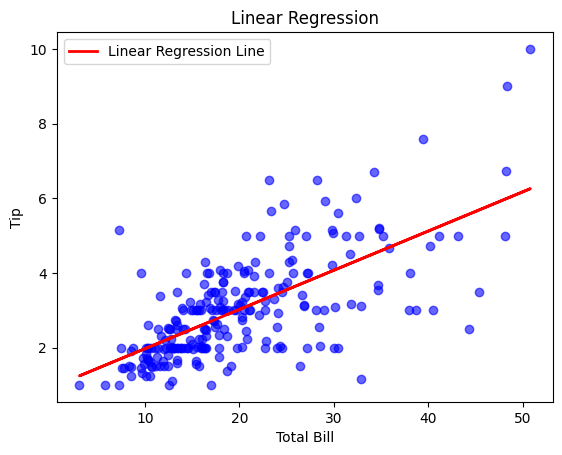

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#데이터 불러오기
tips = sns.load_dataset("tips")
X =tips["total_bill"].values.reshape(-1, 1) # 2차원 행렬로 변환
y =tips["tip"].values

model = LinearRegression() # 아직 학습이 안된 모델 객체 생성
model.fit(X, y) # X,y로 학습 시작

y_hat = model.predict(X)

plt.scatter(X, y, color = 'blue', alpha = 0.6)

plt.plot(X, y_hat, color = 'red', linewidth = 2 , label = 'Linear Regression Line')

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Linear Regression")
plt.legend()
plt.show()


* 이번엔 로지스틱 회귀에 적용해보기
* 아까 작성했던 코드에 Lib를 쓴 코드로 변경

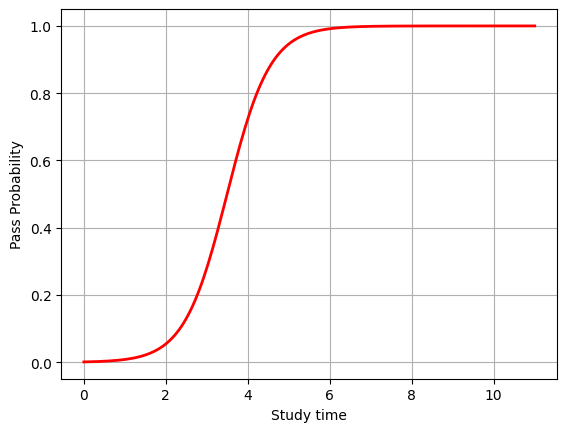

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)

y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

model = LogisticRegression()
model.fit(X, y)

X_new = np.linspace(0, 11, 200).reshape(-1, 1)
y_hat = model.predict_proba(X_new)
y_hat =y_hat[:, 1]

plt.plot(X_new, y_hat, color='red', linewidth=2)
plt.xlabel("Study time")
plt.ylabel("Pass Probability")
plt.grid(True)



# 표준화(전처리)의 필요성
* 데이터를 평균 0, 표준편차 1 형태로 바꾸는 전처리

# 전처리 작업을 하는 이유
## 1번
* 변수 1: 키 160 ~ 190 cm 범위
* 변수 2: 손톱 길이가 0.5cm ~ 1.5cm 범위
* 원본값 그대로 학습하면 키 값 때문에 손톱의 데이터를 보기 어렵다.
* 그래서 아래와 같이 바꿔주면 학습 오작동을 방지할 수 있다.
 * 전처리 후 변수 1 : 키 0 ~ 1 범위
 * 전처리 후 변수 2 : 손톱길이 0 ~ 1 범위

 ## 2번
 * 표준편차가 1이 되도록 데이터를 조율해야 합니다.
  * 값 자체만 본다면 다른 값과 비교가 안된 원본 값 그대로 입니다.
  * 평균에서 얼만큼 벗어난 값인지 수치로 변환하면, 상대적인 값을 확인 수 있습니다.
  * 예시
   * 원본 값 : [32, 99, 15, 38, 39502]
   * 전처리 후 : [하위 2%, 상위 44%, 하위 1%, 하위 2.3%, 상위 0.1%]
  * 전처리 후 데이터로 학습하면 GD 학습이 더 잘됩니다.

# 꼭 평균 0, 표준편차 1로 학습을 해야하는가?
* 모델마다 혹은 수학 계산상 더 좋은 평균과 표준편차가 존재한다면 다른 값으로 해도 무방함.

# 정규화와 표준화의 차이?
* 값의 범위를 조율하는 행동 자체
* 표준화는 "평균0, 표준편차1"로 정규화하는 것을 말합니다.
 * 표준화는 정규화 행동 중 하나이다.

# 표준화 구현하기
 * 표준화는 StandardScaler클래스가 Scikit-learn 포함
 * 표준화를 통해 원본 데이터의 특성을 살리고 학습이 더 잘 될 수 있도록 변경


Text(0, 0.5, 'Tip')

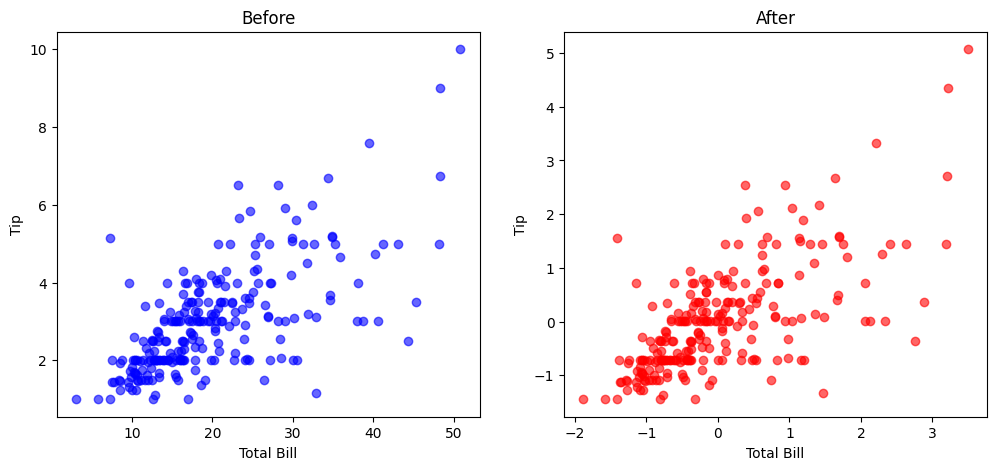

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

#데이터 불러오기
tips = sns.load_dataset("tips")
X =tips["total_bill"].values.reshape(-1, 1) # 2차원 행렬로 변환
y =tips["tip"].values.reshape(-1, 1)

#표준화를 해주는 객체 생성
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X) # fit : 평균과 표준편차 계산하여 내부에 저장
scaler_y.fit(y)

X_std = scaler_X.transform(X) # 변
y_std = scaler_y.transform(y)

fig, axes = plt.subplots(1,2,figsize=(12,5))

# 원본
axes[0].scatter(X,y,color='blue', alpha=0.6)
axes[0].set_title("Before")
axes[0].set_xlabel("Total Bill")
axes[0].set_ylabel("Tip")

# 표준화데이터
axes[1].scatter(X_std,y_std,color='red', alpha=0.6)
axes[1].set_title("After")
axes[1].set_xlabel("Total Bill")
axes[1].set_ylabel("Tip")




# 모델 평가하기

## 모델을 평가하는 이유
* 더 좋은 모델을 만들기 위함이 아니라 학습 도중에 중간 평가를 하여 학습을 조율하기 위함.

## 평가를 위해 데이터를 나눈다

* 평가를 하려면 학습에 사용하지 않은 데이터로 평가해야 합니다.
 * 학습용 데이터 80%
 * 검증용 데이터
 * 테스트 데이터 20%

## Scikit-learn 으로 데이터 나누기

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

#데이터 불러오기
tips = sns.load_dataset("tips")
X =tips["total_bill"].values
y =tips["tip"].values

print("원본 개수 : %d"%X.size)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print()
print(f'Train : {X_train.size}')
print(f'Test : {X_test.size}')

원본 개수 : 244

Train : 195
Test : 49


# Scikit-learn의 마무리